# Install dependencies 
in bash terminal, do:

python -m pip install pandas seaborn matplotlib scikit-learn pydotplus ipykernel

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pydotplus

from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from IPython.display import Image

In [2]:
dataset = pd.read_csv('../dataset/datasets/full_v5.csv')
dataset.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-max()-Z,tBodyAcc-min()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,1","tBodyAcc-arCoeff()-X,2",...,fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)",Activity,subject,split
0,-0.995279,-0.983111,-0.913526,-0.744413,0.814263,-0.407747,-0.679338,-0.602122,0.929294,-0.853011,...,-1.000000,-0.074323,-0.298676,-0.112754,0.030400,-0.464761,-0.018446,STANDING,1,train
1,-0.998245,-0.975300,-0.960322,-0.818409,0.822637,-0.714892,-0.500930,-0.570979,0.611627,-0.329549,...,-1.000000,0.158075,-0.595051,0.053477,-0.007435,-0.732626,0.703511,STANDING,1,train
2,-0.995380,-0.967187,-0.978944,-0.818409,0.839344,-0.592235,-0.485821,-0.570979,0.273025,-0.086309,...,-0.555556,0.414503,-0.390748,-0.118559,0.177899,0.100699,0.808529,STANDING,1,train
3,-0.996091,-0.983403,-0.990675,-0.829711,0.837869,-0.627446,-0.850930,-0.911872,0.061436,0.074840,...,-0.936508,0.404573,-0.117290,-0.036788,-0.012892,0.640011,-0.485366,STANDING,1,train
4,-0.998139,-0.980817,-0.990482,-0.824705,0.837869,-0.786553,-0.559477,-0.761434,0.313276,-0.131208,...,-0.936508,0.087753,-0.351471,0.123320,0.122542,0.693578,-0.615971,STANDING,1,train


In [3]:
from sklearn.preprocessing import LabelEncoder

split = dataset["split"].astype("string").str.lower()
expected_splits = {"train", "test"}
unknown_splits = set(split.dropna().unique()) - expected_splits
if unknown_splits:
    raise ValueError(f"Unexpected values in 'split': {sorted(unknown_splits)}")

# The split column controls the evaluation partition; it is not a model feature.
X = dataset.drop(columns=["Activity", "subject", "split"])
y_text = dataset["Activity"]
groups = dataset["subject"]

le = LabelEncoder()
y = pd.Series(
    le.fit_transform(y_text),
    index=y_text.index,
    name="Activity"
)

print("Encoded mapping:")
for encoded_value, activity in enumerate(le.classes_):
    print(encoded_value, "=", activity)

Encoded mapping:
0 = LAYING
1 = SITTING
2 = STANDING
3 = WALKING
4 = WALKING_DOWNSTAIRS
5 = WALKING_UPSTAIRS


In [4]:
train_mask = split.eq("train")
test_mask = split.eq("test")

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
groups_train, groups_test = groups.loc[train_mask], groups.loc[test_mask]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)
print("Number of overlapping subjects:", len(overlap))
print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))

Subjects in training data:
[np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(23), np.int64(24), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Subjects in test data:
[np.int64(3), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(20), np.int64(22), np.int64(25), np.int64(26)]

Number of training subjects: 21
Number of test subjects: 9

Overlapping subjects: set()
Number of overlapping subjects: 0

Training rows: 7177
Test rows: 3122


In [5]:
# Train/test variables are prepared in the previous cell from the dataset's split column.

In [6]:
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate metrics and the normalized matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

labels = list(range(len(le.classes_)))
cm_percent = confusion_matrix(
    y_test, 
    y_pred, 
    labels=labels, 
    normalize="true"
)

Accuracy: 0.8398462524023063

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       594
           1       0.84      0.79      0.81       555
           2       0.80      0.86      0.83       581
           3       0.85      0.73      0.78       504
           4       0.83      0.80      0.81       414
           5       0.72      0.83      0.77       474

    accuracy                           0.84      3122
   macro avg       0.84      0.83      0.83      3122
weighted avg       0.84      0.84      0.84      3122



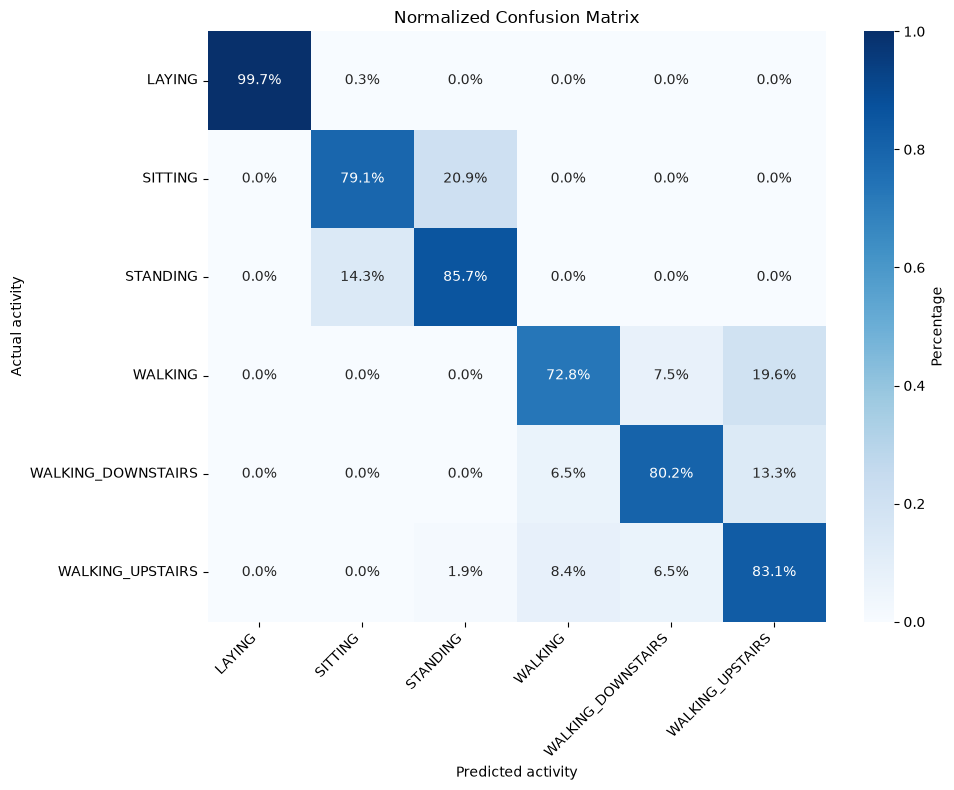

In [7]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={"label": "Percentage"}
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted activity")
plt.ylabel("Actual activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
y_test_names = le.inverse_transform(y_test)
y_pred_names = le.inverse_transform(y_pred)

print(y_pred_names[:10])

['SITTING' 'STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING'
 'STANDING' 'STANDING' 'STANDING' 'STANDING']


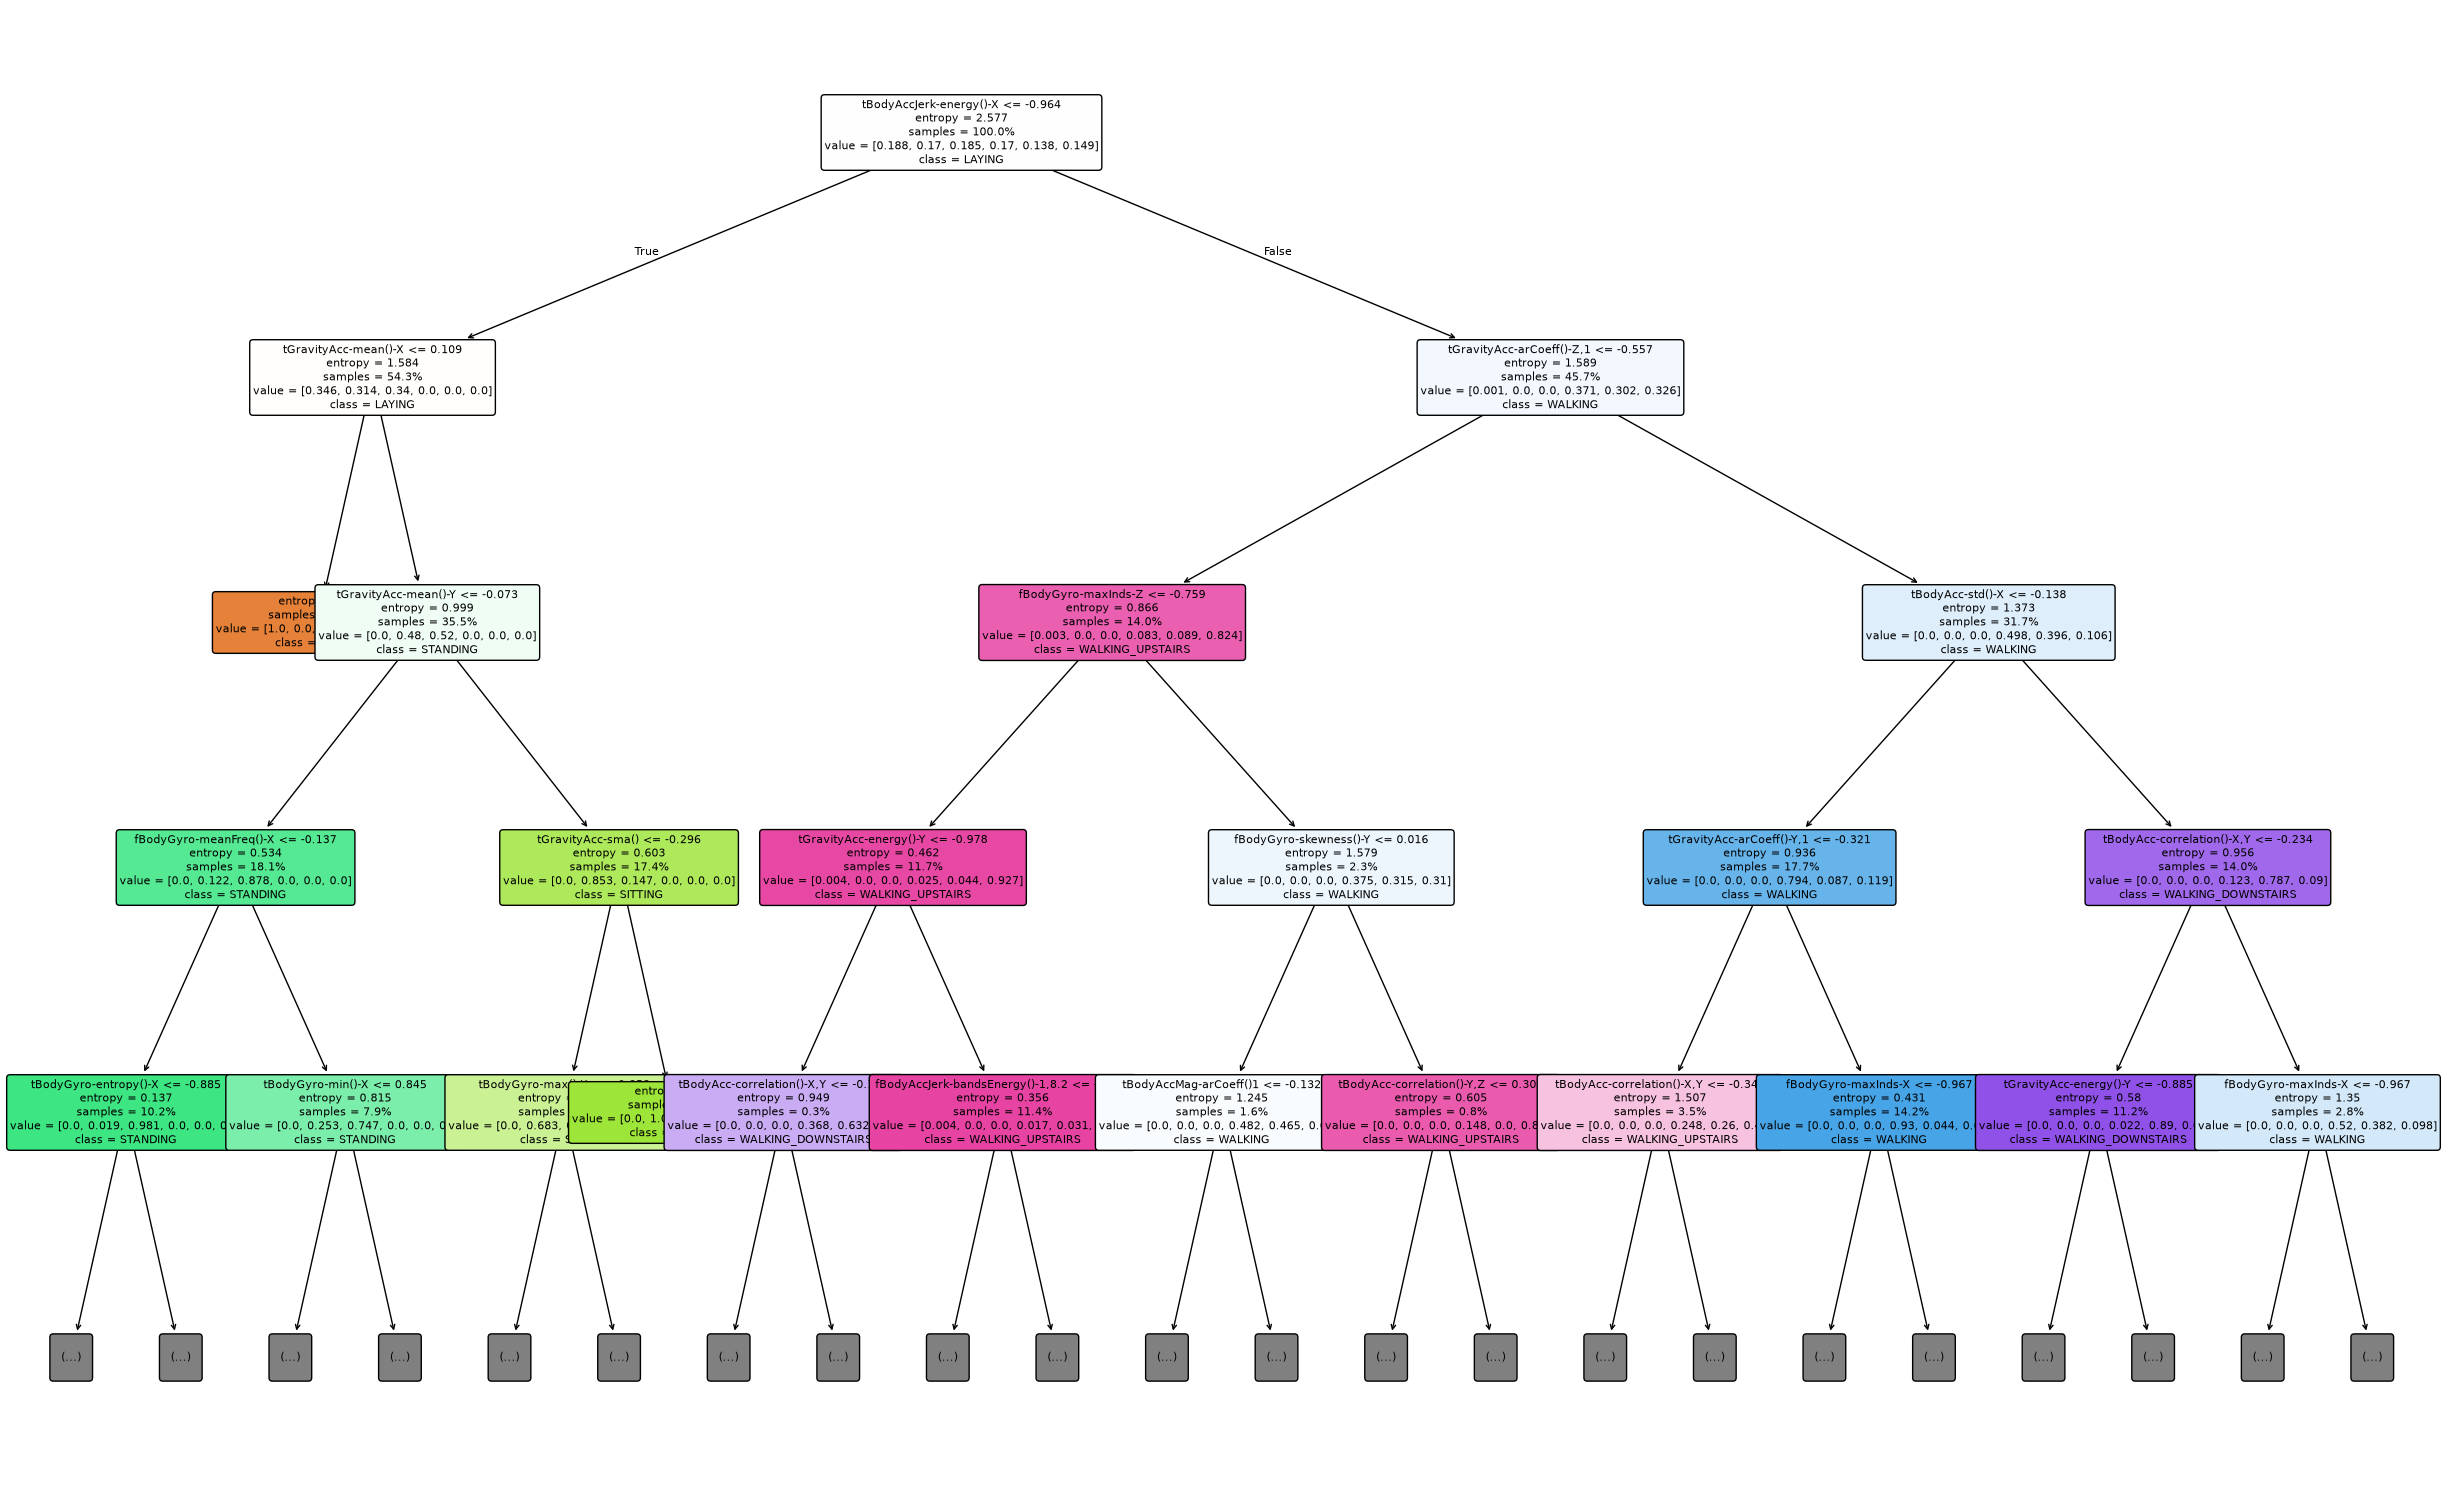

In [9]:
plt.figure(figsize=(25, 15))

tree.plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=le.classes_.astype(str).tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True,
    max_depth=4  # Prevents rendering 69 PCA components into an illegible graph
)

plt.tight_layout()
plt.show()

In [ ]:
model_name = "cart_v5 Decision Tree"
dataset_name = "full_v5"
note = "N/A"

report = classification_report(
    y_test,
    y_pred,
    labels=list(range(len(le.classes_))),
    target_names=le.classes_,
    output_dict=True,
    zero_division=0,
)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=list(range(len(le.classes_))),
    normalize="true",
).round(4).tolist()

record = {
    "timestamp": datetime.now().isoformat(),
    "dataset": dataset_name,
    "model": model_name,
    "note": note or "N/A",
    "overall_accuracy": float(accuracy_score(y_test, y_pred)),
    "macro_f1": float(report["macro avg"]["f1-score"]),
    "classes": le.classes_.tolist(),
    "confusion_matrix_percent": cm_normalized,
    "classification_report": report,
    "params": {
        "learning_rate": None,
        "max_depth": model.get_params().get("max_depth"),
        "n_estimators": None,
        "num_round": None,
        "subsample": None,
        "colsample_bytree": None,
        "min_child_weight": None,
        "criterion": model.get_params().get("criterion"),
        "min_samples_split": model.get_params().get("min_samples_split"),
        "min_samples_leaf": model.get_params().get("min_samples_leaf"),
        "random_state": model.get_params().get("random_state"),
    },
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(record) + "\n")

print(
    f"Logged {record['model']} on dataset "
    f"'{record['dataset']}' to results.jsonl"
)

Logged cart_v4 Decision Tree on dataset 'full_v5' to results.jsonl
